# Integrate ATAC between In vitro and In vivo multiome based on ATAC

In [1]:
here::i_am("multiome_atlas_integration/integrate_ATAC.ipynb")

suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(batchelor))
suppressPackageStartupMessages(library(uwot))


# Load default settings
source(here::here("settings.R"))
source(here::here("utils.R"))

BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 16

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code

Warning message:
“package ‘destiny’ was built under R version 4.1.3”


In [253]:
args <- list()
# in vitro
args$sce_query <-file.path(io$basedir,"processed/atac/archR/Matrices/PeakMatrix_atlas_summarized_experiment.rds")
args$metadata_query <- file.path(io$basedir, '/results/atac/archR/qc/sample_metadata_after_qc.txt.gz')

# in vivo
io$atlas.basedir = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/'
args$sce_atlas <-file.path(io$atlas.basedir,"data/processed/atac/archR/Matrices/PeakMatrix_summarized_experiment.rds")
args$metadataRNA_atlas <- file.path(io$atlas.basedir,"results/rna/mapping/sample_metadata_after_mapping.txt.gz")
args$metadataATAC_atlas <- file.path(io$atlas.basedir, '/results/atac/archR/qc/sample_metadata_after_qc.txt.gz')
args$celltype_label <- "celltype"

args$sample <- c('E7.5_rep1','E7.5_rep2','E7.75_rep1','E8.0_rep1','E8.0_rep2','E8.5_rep1','E8.5_rep2','E8.75_rep1','E8.75_rep2')

# LSI
args$ntop = 55000
args$ndims = 25

# Trajectory 
opts$celltypes = c("Epiblast",
                    "Primitive_Streak" ,
                    "Anterior_Primitive_Streak",
                    "Nascent_mesoderm",
                    "Intermediate_mesoderm", 
                    "Pharyngeal_mesoderm",
                    "ExE_mesoderm",
                    "Mixed_mesoderm",
                    "Allantois",
                    "Mesenchyme",
                    "Haematoendothelial_progenitors",
                    "Endothelium",
                    "Blood_progenitors_1",
                    "Blood_progenitors_2",
                    "Erythroid1",
                    "Erythroid2",
                    "Erythroid3",
                    "PGC",
                    "Surface_ectoderm")

# I/O
args$outdir = file.path(io$basedir, 'results/multiome_atlas_integration/atac')
dir.create(args$outdir, showWarnings=F, recursive=T)

In [254]:
io$basedir

[1] "/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood"

### In vitro

In [255]:
#########################
## Load in vitro ATAC  ##
#########################
metadata_query <- fread(args$metadata_query) %>%
  .[pass_rnaQC==TRUE & doublet_call==FALSE & pass_atacQC==TRUE]

#############################
## Load ATAC accessibility ##
#############################

sce = readRDS(args$sce_query)

sce = sce[,metadata_query$cell]
sce = as(sce, 'SingleCellExperiment')

# Filter regions accessibile in 5% of cells
nCells = 0.05 * nrow(metadata_query)
region_counts = rowSums(assay(sce, 'PeakMatrix_atlas')>0)
keep_regions = region_counts[region_counts>nCells]
sce = sce[names(keep_regions), ]

assay(sce, 'counts') = assay(sce, 'PeakMatrix_atlas')
assay(sce, 'PeakMatrix_atlas') = NULL

colData(sce) <- metadata_query %>% as.data.frame %>% tibble::column_to_rownames("cell") %>%
  .[colnames(sce),] %>% DataFrame()

sce_query = sce

In [256]:
table(metadata_query$celltype)


                     Allantois      Anterior_Primitive_Streak 
                          3213                            445 
           Blood_progenitors_1            Blood_progenitors_2 
                            86                            138 
               Caudal_epiblast                Caudal_Mesoderm 
                            49                              3 
                 Def._endoderm                    Endothelium 
                            48                            416 
                      Epiblast                     Erythroid1 
                           680                             91 
                    Erythroid2                   ExE_endoderm 
                             3                              1 
                  ExE_mesoderm   Forebrain_Midbrain_Hindbrain 
                          4990                             58 
                           Gut Haematoendothelial_progenitors 
                            43                        

### In Vivo

In [257]:
##########################
## Load sample metadata ##
##########################

metadata_atlas <- fread(args$metadataRNA_atlas) %>%
  .[pass_rnaQC==TRUE & doublet_call==FALSE] %>%
    merge(.,fread(args$metadataATAC_atlas)[,c('cell', 'pass_atacQC')], by='cell') %>%
    .[pass_atacQC==TRUE]

stopifnot(args$celltype_label%in%colnames(metadata_atlas))
metadata_atlas <- metadata_atlas   %>%
  .[,celltype:=eval(as.name(args$celltype_label))] %>%
  .[celltype%in%opts$celltypes] %>%
  .[,celltype:=factor(celltype,levels=opts$celltypes)] %>%
  .[sample%in% args$sample]

table(metadata_atlas$celltype)

#############################
## Load ATAC accessibility ##
#############################
  
sce = readRDS(args$sce_atlas)
sce = sce[,metadata_atlas$cell]
sce = as(sce, 'SingleCellExperiment')

# Filter regions accessibile in 5% of cells
nCells = 0.05 * nrow(metadata_atlas)
region_counts = rowSums(assay(sce, 'PeakMatrix')>0)
keep_regions = region_counts[region_counts>nCells]
sce = sce[names(keep_regions), ]

assay(sce, 'counts') = assay(sce, 'PeakMatrix')
assay(sce, 'PeakMatrix') = NULL

colData(sce) <- metadata_atlas %>% as.data.frame %>% tibble::column_to_rownames("cell") %>%
  .[colnames(sce),] %>% DataFrame()

sce_atlas = sce


                      Epiblast               Primitive_Streak 
                           984                            542 
     Anterior_Primitive_Streak               Nascent_mesoderm 
                           138                           1327 
         Intermediate_mesoderm            Pharyngeal_mesoderm 
                           808                           1710 
                  ExE_mesoderm                 Mixed_mesoderm 
                          1173                            265 
                     Allantois                     Mesenchyme 
                           653                           3123 
Haematoendothelial_progenitors                    Endothelium 
                           913                            666 
           Blood_progenitors_1            Blood_progenitors_2 
                           230                            565 
                    Erythroid1                     Erythroid2 
                          1119                        

### Merge

In [258]:
overlapping_regions = intersect(rownames(sce_query), rownames(sce_atlas))

In [259]:
sce_atlas = sce_atlas[overlapping_regions,]
sce_query = sce_query[overlapping_regions,]

In [260]:
colnames(colData(sce_atlas))
colnames(colData(sce_query))

[1] "barcode"                   "sample"                   
 [3] "nFeature_RNA"              "nCount_RNA"               
 [5] "mitochondrial_percent_RNA" "ribosomal_percent_RNA"    
 [7] "stage"                     "genotype"                 
 [9] "pass_rnaQC"                "doublet_score"            
[11] "doublet_call"              "celltype"                 
[13] "celltype.score"            "closest.cell"             
[15] "pass_atacQC"

[1] "barcode"                   "sample"                   
 [3] "nFeature_RNA"              "nCount_RNA"               
 [5] "mitochondrial_percent_RNA" "ribosomal_percent_RNA"    
 [7] "alias"                     "day"                      
 [9] "genotype"                  "pass_rnaQC"               
[11] "doublet_score"             "doublet_call"             
[13] "celltype"                  "celltype.score"           
[15] "closest.cell"              "day_celltype"             
[17] "celltype_genotype"         "TSSEnrichment_atac"       
[19] "ReadsInTSS_atac"           "PromoterRatio_atac"       
[21] "NucleosomeRatio_atac"      "nFrags_atac"              
[23] "BlacklistRatio_atac"       "pass_atacQC"

In [261]:
colData(sce_query) <- colData(sce_query) %>% 
    as.data.table(keep.rownames=T) %>% 
    .[,c('rn', 'sample', 'day', 'celltype', 'genotype')] %>% 
    setnames(c('cell', 'sample', 'stage', 'celltype', 'genotype')) %>%
    as.data.frame %>% tibble::column_to_rownames("cell") %>% 
    DataFrame()

colData(sce_atlas) <- colData(sce_atlas) %>% 
    as.data.table(keep.rownames=T) %>% 
    .[,c('rn', 'sample', 'stage', 'celltype', 'genotype')] %>% 
    setnames(c('cell', 'sample', 'stage', 'celltype', 'genotype')) %>%
    as.data.frame %>% tibble::column_to_rownames("cell") %>% 
    DataFrame()

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”
Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


In [262]:
sce = cbind(sce_atlas, sce_query)

In [263]:
atac.counts = counts(sce)

In [264]:
###################
## Iterative LSI ##
###################

## First round of LSI on just top accessible features

# Extract top accessible features for both datasets
top_query = rowMeans(counts(sce_query))
top_query = top_query[order(-top_query)]

top_atlas = rowMeans(counts(sce_atlas))
top_atlas = top_atlas[order(-top_atlas)]

# get overlap of top 40k features
top = intersect(names(head(top_query, args$ntop )), names(head(top_atlas, args$ntop )))
length(top) # 35k correspond between in vivo & in vitro, which is a good sign

# TFIDF normalisation
atac_tfidf.mtx <- tfidf(atac.counts[top,], method=1, scale.factor=1e4)

# LSI
svd <- irlba::irlba(atac_tfidf.mtx, args$ndims, args$ndims)
svdDiag <- matrix(0, nrow=args$ndims, ncol=args$ndims)
diag(svdDiag) <- svd$d
svd.mtx <- t(svdDiag %*% t(svd$v))
rownames(svd.mtx) <- colnames(sce)
colnames(svd.mtx) <- paste0("LSI",seq_len(ncol(svd.mtx)))

rm(svd,svdDiag)

[1] 49304

In [265]:
summary(rownames(svd.mtx) == colnames(sce))

   Mode    TRUE 
logical   51163 

In [266]:
# clustering in Seurat
library(Seurat)

# Create object
seurat = CreateSeuratObject(
  counts = counts(sce))
# Add LSI
seurat[['LSI']] = CreateDimReducObject(embeddings = svd.mtx, key = "LSI_", assay = DefaultAssay(seurat))
# Find clusters
seurat <- FindNeighbors(seurat, dims = 1:args$ndims, reduction = 'LSI')
seurat <- FindClusters(seurat, resolution = 0.3, reduction = 'LSI')
clusters = seurat@meta.data$seurat_clusters

# Find variable features across clusters 
sce_pb = aggregateAcrossCells(sce, id=clusters, BPPARAM = BPPARAM, statistics='mean')
region_vars = rowVars(counts(sce_pb))
names(region_vars) = rownames(sce_pb)


## second round of LSI on top variable features

region_vars = region_vars[order(-region_vars)]
# get overlap of top 40k features
top = names(head(region_vars, args$ntop))

# TFIDF normalisation
atac_tfidf.mtx <- tfidf(atac.counts[top,], method=1, scale.factor=1e4)

# LSI
svd <- irlba::irlba(atac_tfidf.mtx, args$ndims, args$ndims)
svdDiag <- matrix(0, nrow=args$ndims, ncol=args$ndims)
diag(svdDiag) <- svd$d
svd.mtx <- t(svdDiag %*% t(svd$v))
rownames(svd.mtx) <- colnames(sce)
colnames(svd.mtx) <- paste0("LSI",seq_len(ncol(svd.mtx)))

rm(svd,svdDiag)

Computing nearest neighbor graph

Computing SNN

Warning message:
“The following arguments are not used: reduction”
Warning message:
“The following arguments are not used: reduction”


Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 51163
Number of edges: 1676686

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9369
Number of communities: 12
Elapsed time: 13 seconds


In [267]:
svd.dt = as.data.table(svd.mtx, keep.rownames=T) %>% setnames('rn', 'cell')

In [268]:
fwrite(svd.dt, sprintf("%s/LSI.txt.gz",args$outdir))

In [269]:
head(svd.dt)

cell,LSI1,LSI2,LSI3,LSI4,LSI5,LSI6,LSI7,LSI8,LSI9,⋯,LSI16,LSI17,LSI18,LSI19,LSI20,LSI21,LSI22,LSI23,LSI24,LSI25
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
E7.5_rep1#AAACAGCCATCCTGAA-1,38.48830,-5.671146,-0.8720624,-3.318568,5.2838655,-5.402342,5.4855269,-8.4531301,-5.8846291,⋯,-1.047417,2.358199,-0.2978390,-1.9243554,4.0561718,0.6044917,1.7302309,0.2687813,-1.689328285,0.0437197
E7.5_rep1#AAACAGCCATGCTATG-1,46.27982,-12.757766,0.2964589,-4.477612,-5.0614366,-4.362633,2.1037122,-6.4045121,-3.6644771,⋯,-1.854145,3.080295,-2.4738994,1.5678762,-1.5677221,-2.6113951,-0.6482654,0.9227972,0.036001844,0.2293023
E7.5_rep1#AAACATGCAGGATAAC-1,16.97759,3.528330,8.4794812,-1.020942,2.7154763,-0.258262,-0.6943204,-0.8086149,-0.4902776,⋯,2.114954,1.163914,-0.6123463,0.9485131,-0.7018809,0.3438745,1.4830278,-0.6560218,0.002995472,0.7981161
E7.5_rep1#AAACCGGCAACCCTAA-1,50.13977,-11.920673,0.7792672,-3.247011,-1.4597626,-3.784013,4.7453806,-4.9765119,-3.4841696,⋯,-1.644988,2.294640,-1.2183071,-0.7650963,-1.1884721,-1.5550111,2.6247124,1.8718416,0.251099961,0.2605653
E7.5_rep1#AAACCGGCAACCTAAT-1,44.44564,9.344058,15.1343677,4.343580,0.9612523,-9.057037,0.3940509,-2.9980844,0.6264442,⋯,5.378641,2.783796,-1.5947193,0.4276773,-0.9088050,0.8441894,1.5630235,-2.3578112,1.091601200,0.7148522
E7.5_rep1#AAACGGATCACGCCAA-1,47.47655,-13.563382,2.9942564,-6.053782,-6.6713068,-3.281374,2.0833824,-4.5226964,-2.7129604,⋯,-1.641846,1.829577,-1.9915882,0.5832846,-2.6209403,-2.6232368,0.1133690,-0.6732507,-0.250673706,0.7627624


In [270]:
######################
## Batch correction ##
######################
pca.mtx = svd.mtx
sample_metadata = as.data.table(colData(sce), keep.rownames=T) %>% setnames('rn', 'cell')

# Define stage and sample order
stopifnot(sample_metadata$cell==rownames(pca.mtx))
timepoints <- sample_metadata$stage
timepoint_order <- c('E8.75', 'E8.5', 'E8.0', 'E7.75', 'E7.5', 'D5', 'D4.5', 'D4', 'D3.5', 'D3')
samples <- sample_metadata$sample
sample_order = as.data.table(table(sample_metadata$sample))[order(-N), V1] # order from most to least cells

pca_list    <- lapply(unique(timepoints), function(i){
    sub_pc   <- pca.mtx[timepoints == i, , drop = FALSE]
    sub_samp <- samples[timepoints == i]
    list     <- lapply(unique(sub_samp), function(j){ sub_pc[sub_samp == j, , drop = FALSE]})
    names(list) <- unique(sub_samp)
    return(list)
})
names(pca_list) <- unique(timepoints)

#arrange to match timepoint order
pca_list <- pca_list[order(match(names(pca_list), timepoint_order))]
pca_list <- lapply(pca_list, function(x){ x[order(match(names(x), sample_order))]})

#perform corrections within stages
correct_list <- lapply(pca_list, function(x){
if(length(x) > 1){
  return(do.call(reducedMNN, x)$corrected)
} else {
  return(x[[1]])
}
})

# perform correction over stages
pca.corrected <- reducedMNN(correct_list, merge.order=1:length(correct_list))$corrected 
colnames(pca.corrected) <- paste0("PC",1:ncol(pca.corrected))
rm(correct_list,pca_list)

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


In [271]:
LSI.corrected = pca.corrected
colnames(LSI.corrected) = paste0('LSI', 1:dim(LSI.corrected)[2])

In [272]:
get_umap = function(ndims = args$ndims, n_neighbors = 25, min_dist=0.3, plot=FALSE){
    umap.mtx = umap(LSI.corrected[,1:ndims], 
                    n_neighbors = n_neighbors,
                    min_dist = min_dist)

    # Fetch UMAP coordinates
    umap.dt <- umap.mtx %>% as.data.table(keep.rownames=T) %>% setnames('rn', 'cell') %>% 
      setnames(c("cell", "UMAP1","UMAP2")) %>%
      merge(.,sample_metadata[,c('cell', 'celltype', 'stage', 'genotype')], by='cell')

    # Plot umap
    p1 = ggplot(umap.dt, aes(UMAP1, UMAP2, col=celltype)) + 
        geom_point() + 
        scale_colour_manual(values=opts$celltype.colors) + 
        ggtitle('celltype') + 
        theme_void() + 
        theme(legend.position="none")
    p2 = ggplot(umap.dt, aes(UMAP1, UMAP2, col=genotype)) + 
        geom_point() + 
        ggtitle('celltype') + 
        theme_void() + 
        theme(legend.position="none")
    options(repr.plot.width=20, repr.plot.height=6)
    
    if(plot==TRUE){ggarrange(p1, p2)}
    else{return(umap.dt)}
    
}

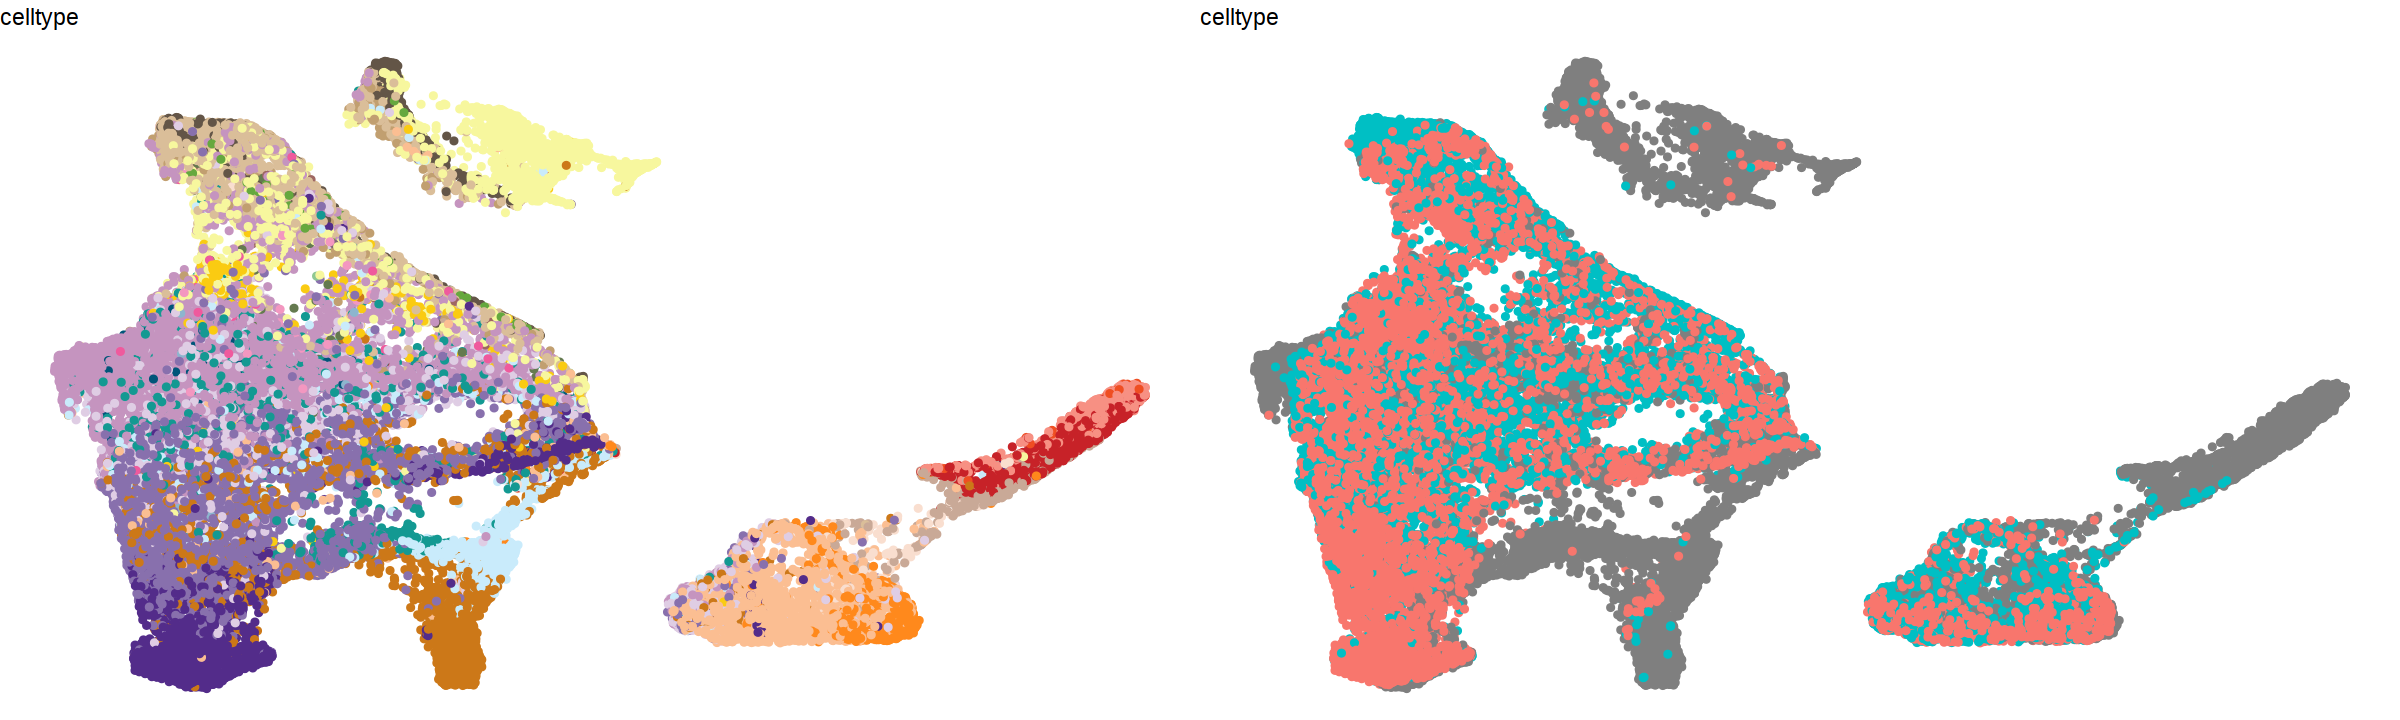

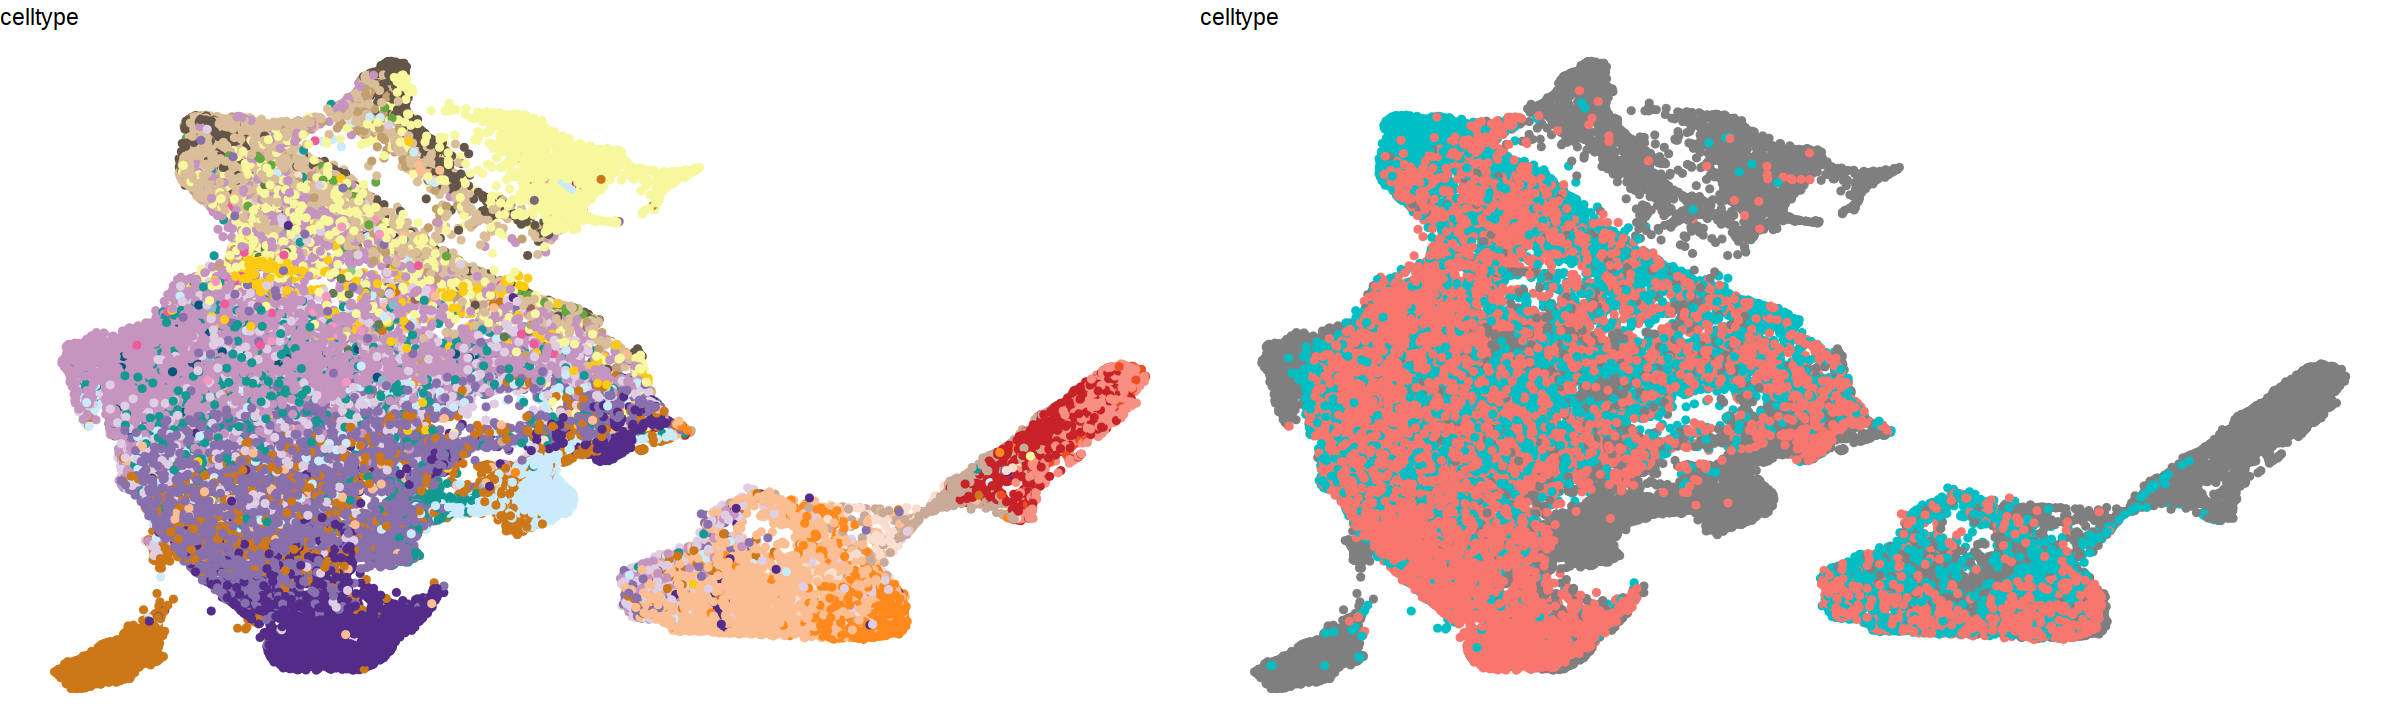

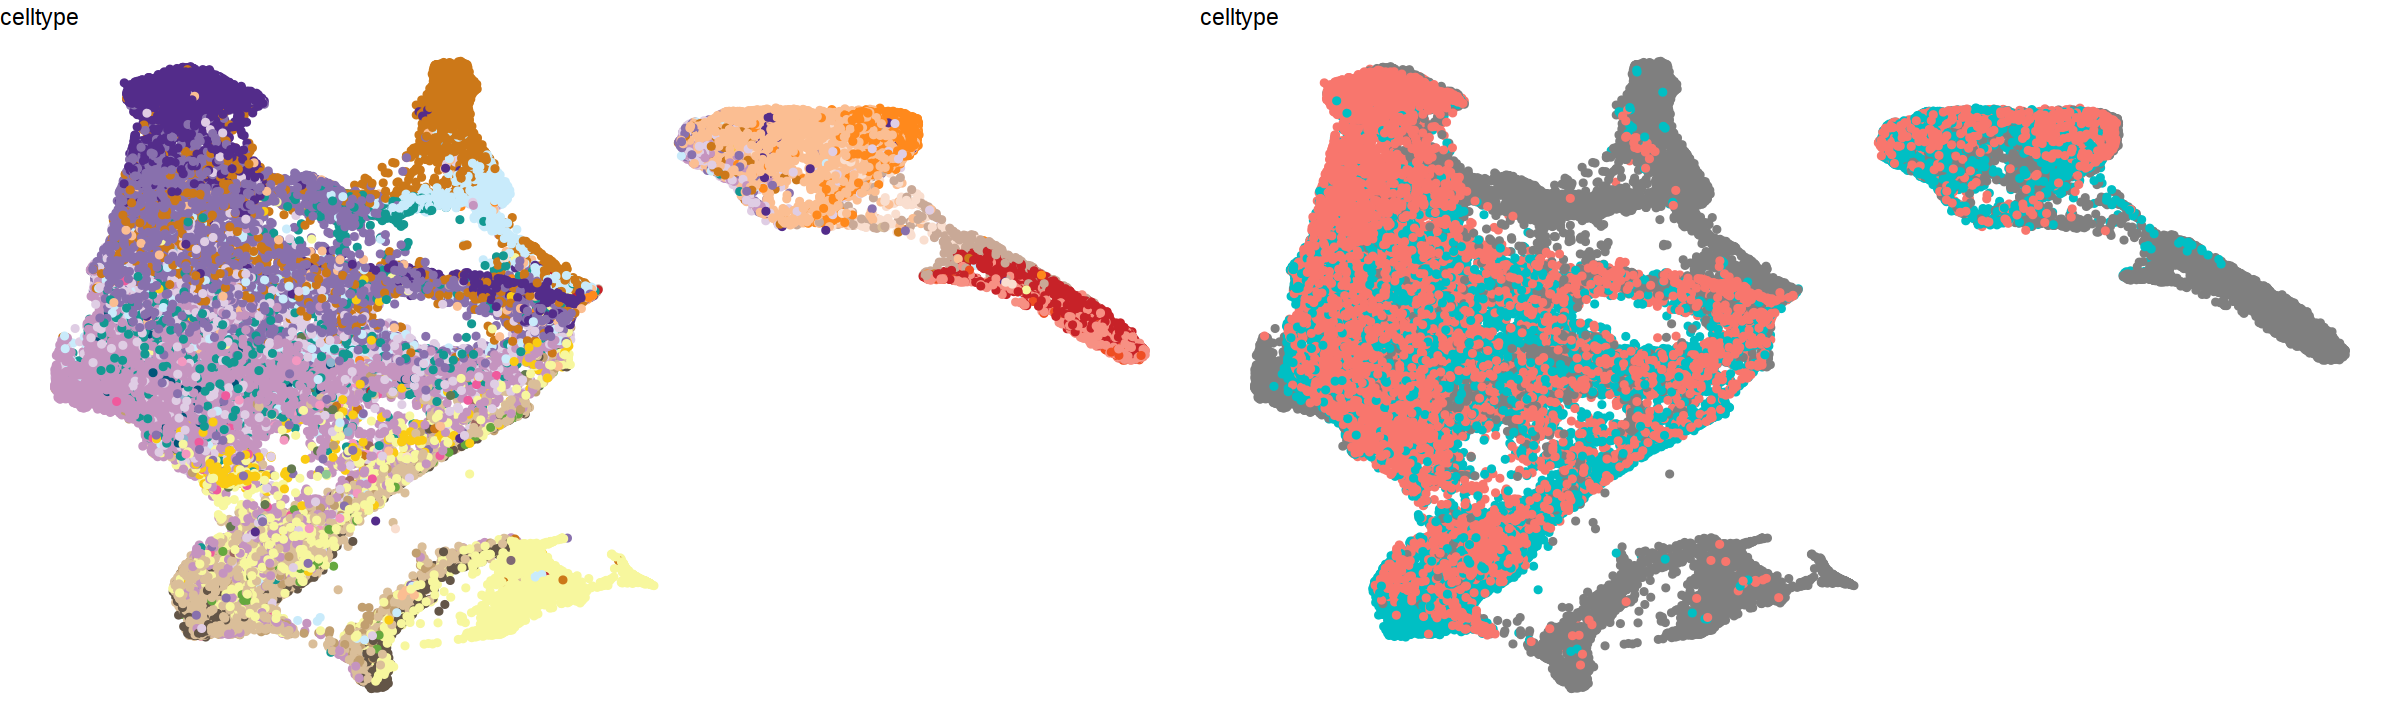

In [273]:
get_umap(n_neighbors =  20, min_dist= 0.01, plot=TRUE)
get_umap(n_neighbors =  20, min_dist= 0.1, plot=TRUE)
get_umap(n_neighbors =  25, min_dist= 0.01, plot=TRUE)

In [274]:
get_umap(35, 55, 0.8, plot=TRUE)


ERROR: Error in LSI.corrected[, 1:ndims]: subscript out of bounds


In [210]:
#batch correction only based on origin
sample_metadata = sample_metadata %>%
    .[,origin:=ifelse(is.na(genotype), 'atlas', 'query')]

In [215]:
split.lsi = lapply(unique(sample_metadata$origin), function(x){
    tmp = svd.mtx[sample_metadata$origin == x, ]
    return(tmp)})

In [218]:
pca.corrected <- reducedMNN(split.lsi, merge.order=1:length(split.lsi))$corrected 

In [219]:
LSI.corrected = pca.corrected
colnames(LSI.corrected) = paste0('LSI', 1:dim(LSI.corrected)[2])

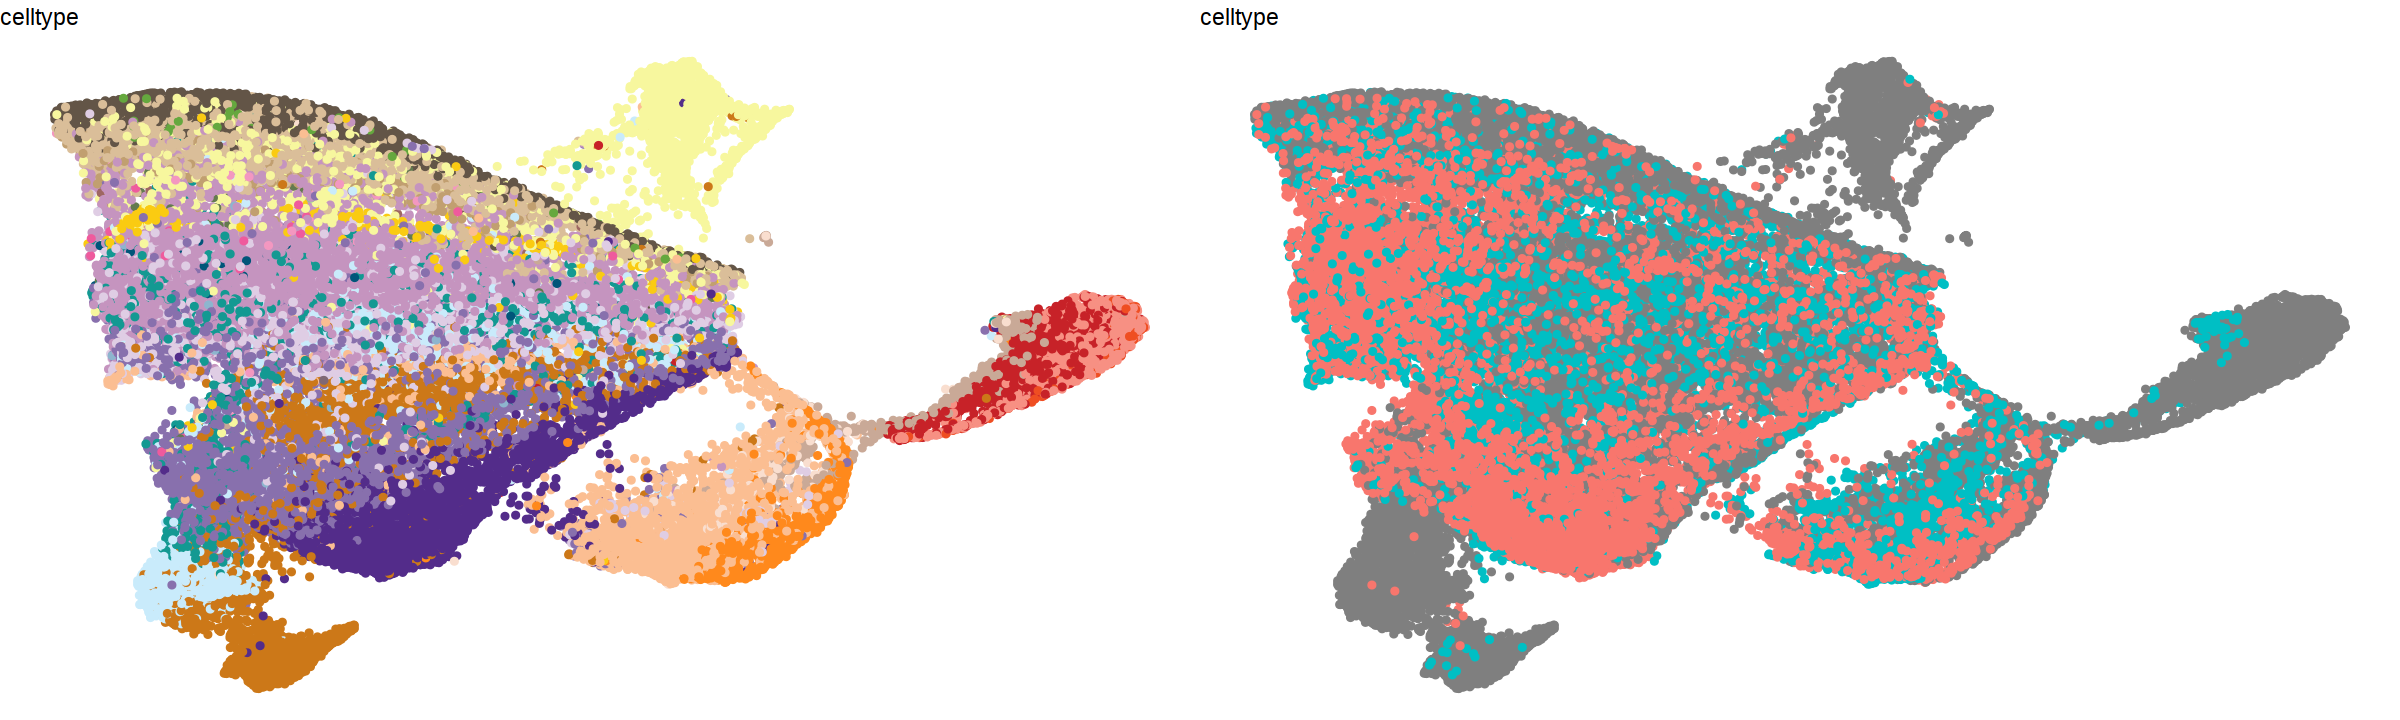

In [222]:
get_umap(35, 20, 0.2, plot=TRUE)


In [224]:
sample_order =  as.data.table(table(sample_metadata$sample))[order(-N), V1]

split.lsi = lapply(sample_order, function(x){
    tmp = svd.mtx[sample_metadata$sample == x, ]
    return(tmp)})

In [225]:
pca.corrected <- reducedMNN(split.lsi, merge.order=1:length(split.lsi))$corrected 

In [226]:
LSI.corrected = pca.corrected
colnames(LSI.corrected) = paste0('LSI', 1:dim(LSI.corrected)[2])

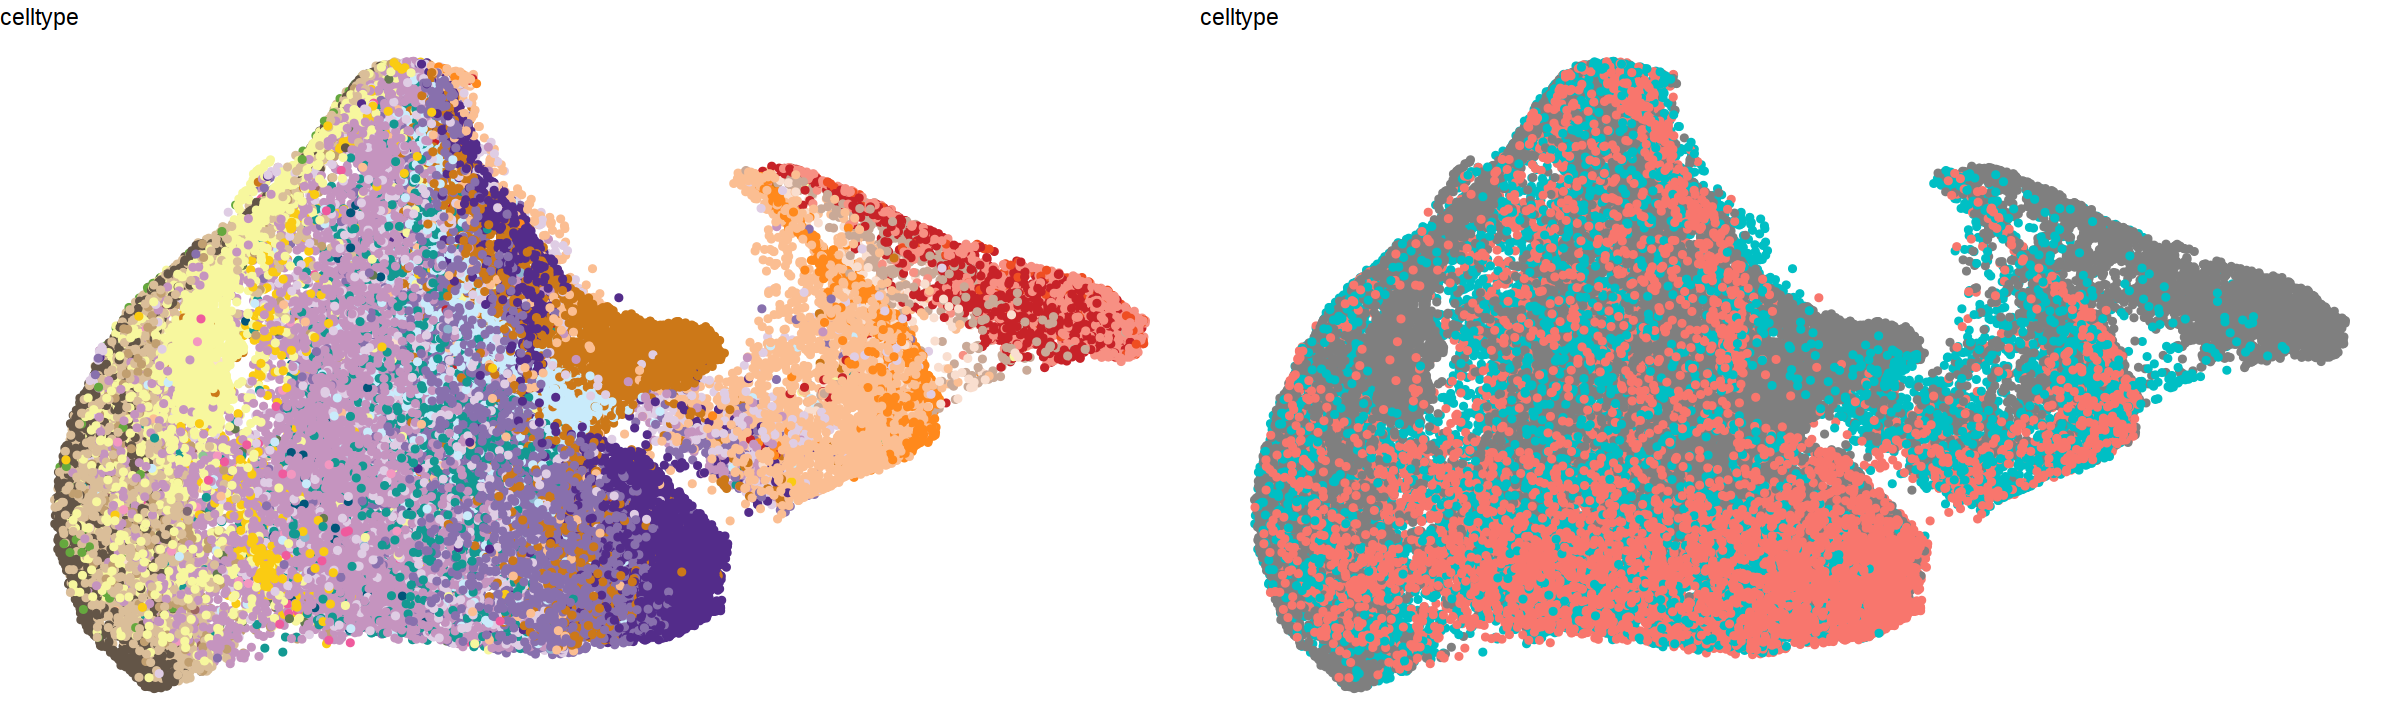

In [227]:
get_umap(35, 20, 0.2, plot=TRUE)


In [228]:
get_umap = function(ndims = 35, n_neighbors = 25, min_dist=0.3, plot=FALSE){
    umap.mtx = umap(svd.mtx[,1:ndims], 
                    n_neighbors = n_neighbors,
                    min_dist = min_dist)

    # Fetch UMAP coordinates
    umap.dt <- umap.mtx %>% as.data.table(keep.rownames=T) %>% setnames('rn', 'cell') %>% 
      setnames(c("cell", "UMAP1","UMAP2")) %>%
      merge(.,sample_metadata[,c('cell', 'celltype', 'stage', 'genotype')], by='cell')

    # Plot umap
    p1 = ggplot(umap.dt, aes(UMAP1, UMAP2, col=celltype)) + 
        geom_point() + 
        scale_colour_manual(values=opts$celltype.colors) + 
        ggtitle('celltype') + 
        theme_void() + 
        theme(legend.position="none")
    p2 = ggplot(umap.dt, aes(UMAP1, UMAP2, col=genotype)) + 
        geom_point() + 
        ggtitle('celltype') + 
        theme_void() + 
        theme(legend.position="none")
    options(repr.plot.width=20, repr.plot.height=6)
    
    if(plot==TRUE){ggarrange(p1, p2)}
    else{return(umap.dt)}
    
}

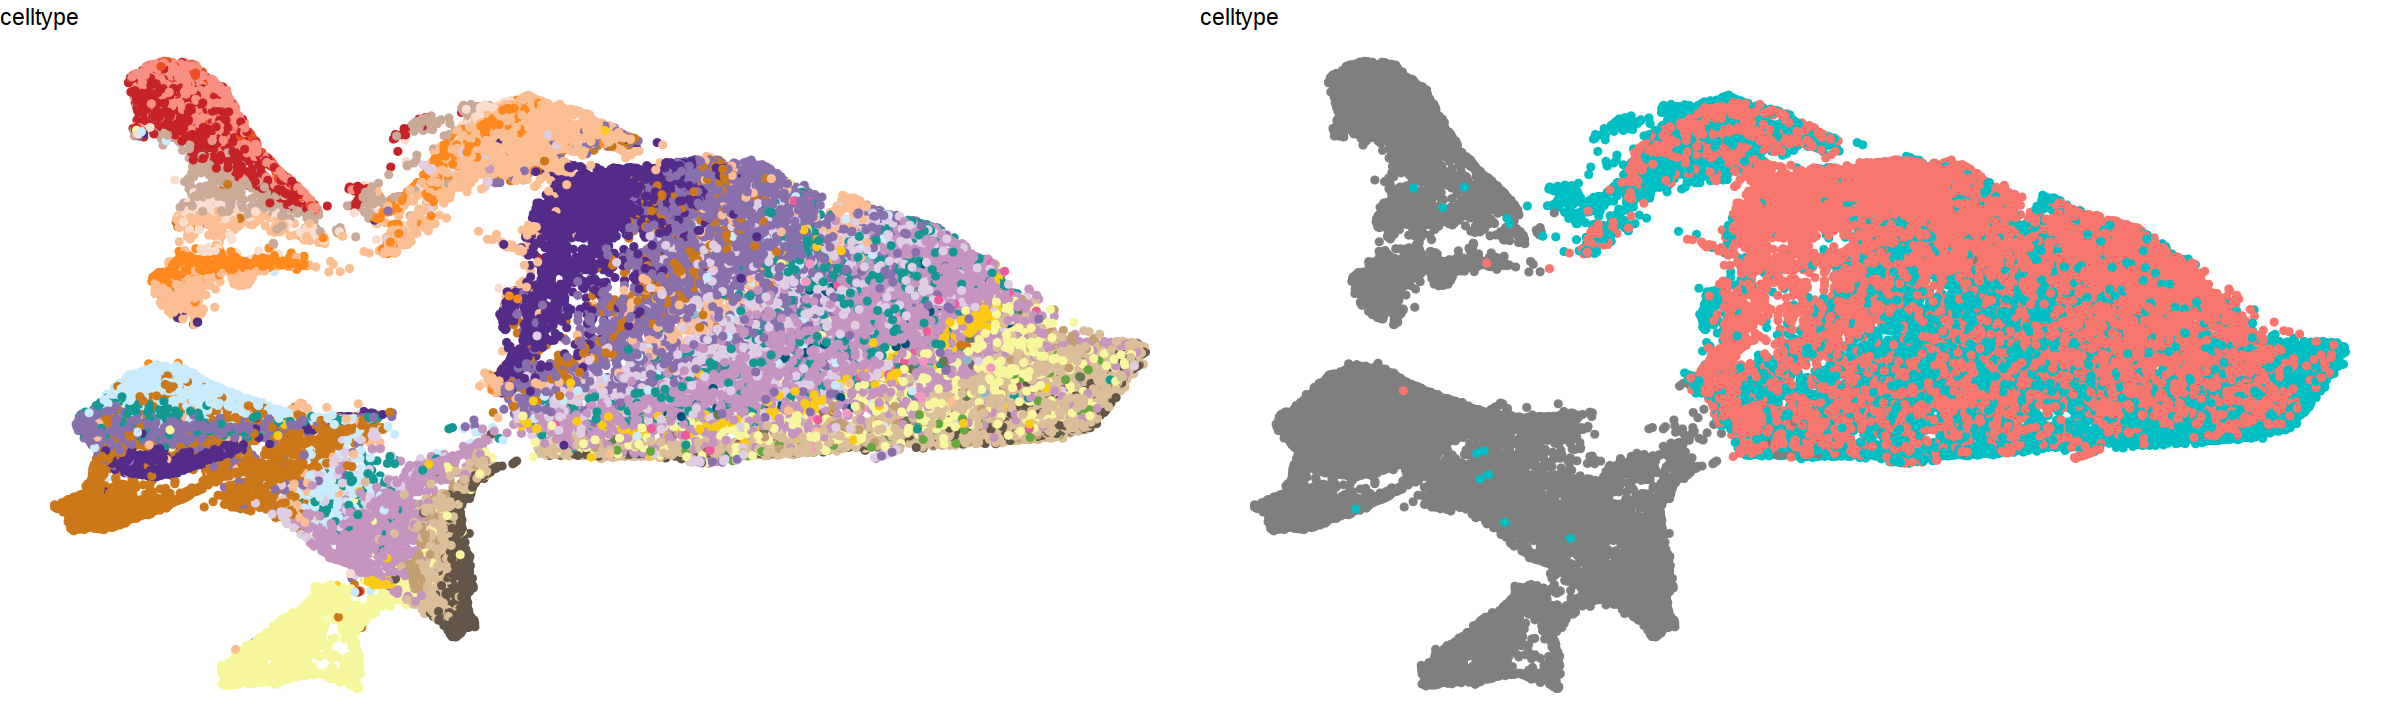

In [229]:
get_umap(35, 20, 0.2, plot=TRUE)
